Импортируем библиотеки:

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)
print("yes")

yes


Читаем наш датасет:

In [4]:
df = pd.read_csv("student_lifestyle_100k.csv")
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


## Этап 1: Проведем разведочный анализ (EDA)

### Проверка типов данных
Во-первых, проверим типы данных всех столбцов, чтобы в дальнейшем предсказуемо с нми работать (строить графики и т.д.):

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  str    
 3   Department          100000 non-null  str    
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), str(2)
memory usage: 7.7 MB


Видим, что типы данных везде соответствуют содержимому (никакое число не записано как строка или что-либо подобное). Здесь также видим, что в датасете нет пропусков, но этим мы займемся позже.

### Визуализация данных
Теперь сделаем визуализацию наших данных, чтобы понимать размер набора данных, их распределение, наличие пропусков, дубликатов и аномалий. Это даст нам хорошее представление о том, с чем мы вообще работаем.

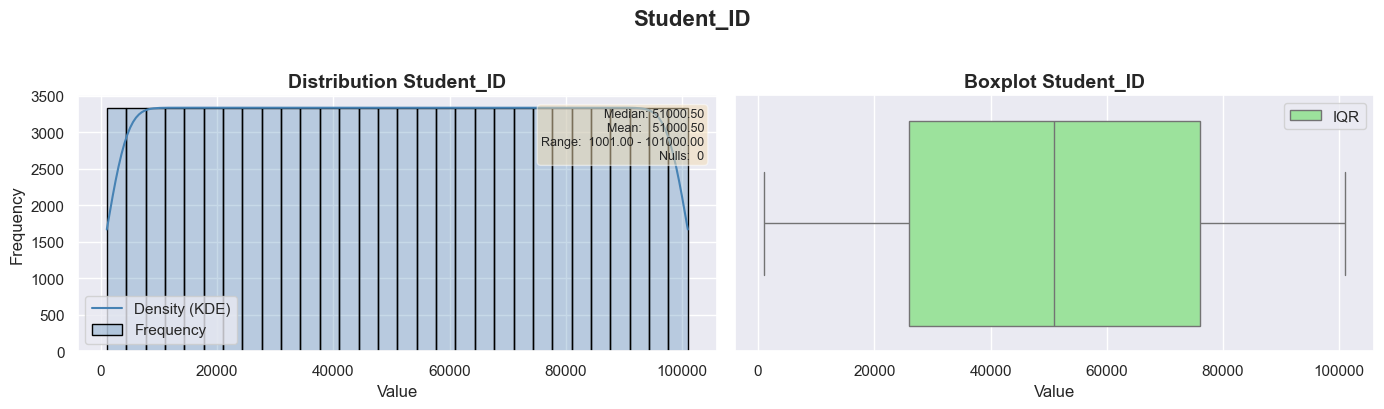

Student_ID:
Пропусков: 0
Выбросов: 0


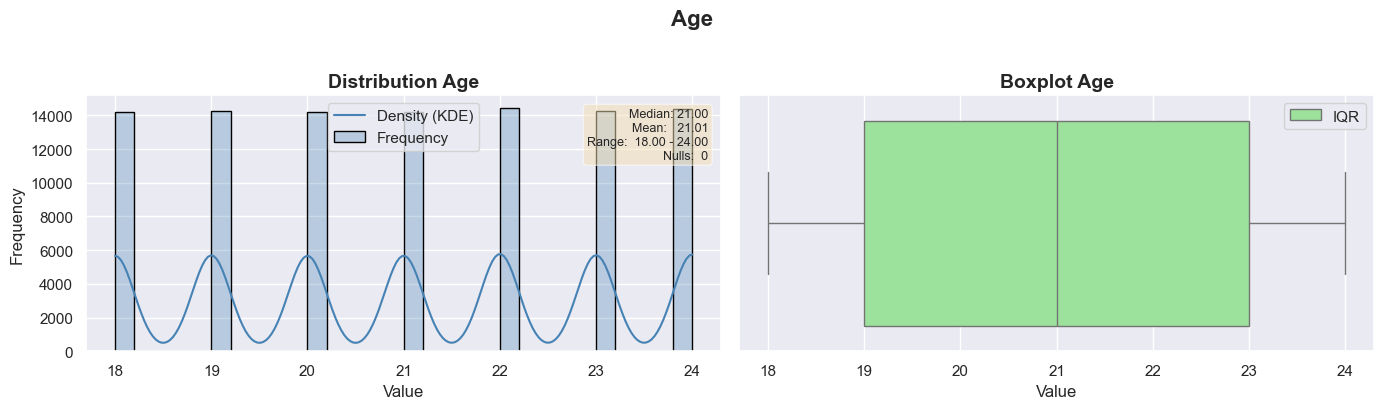

Age:
Пропусков: 0
Выбросов: 0


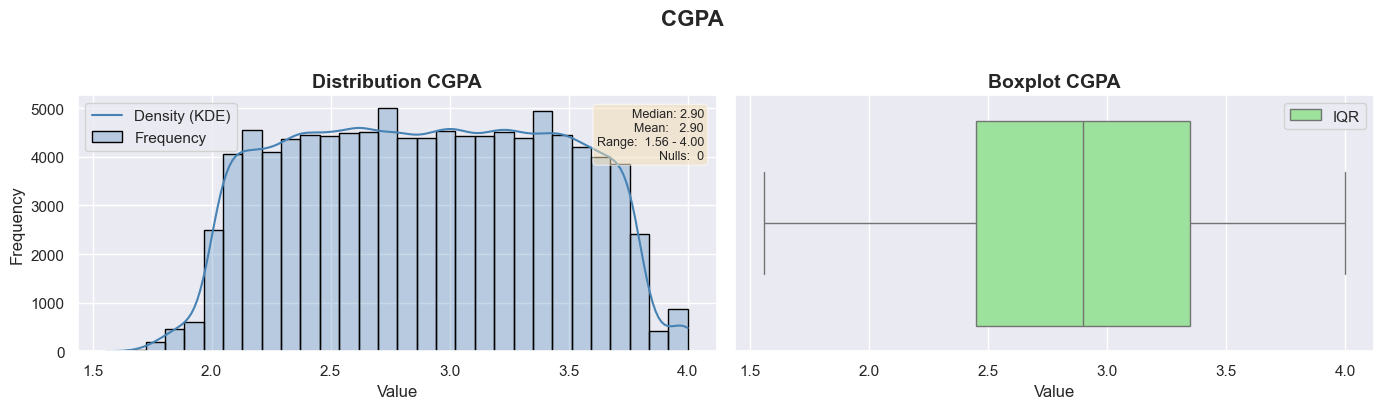

CGPA:
Пропусков: 0
Выбросов: 0


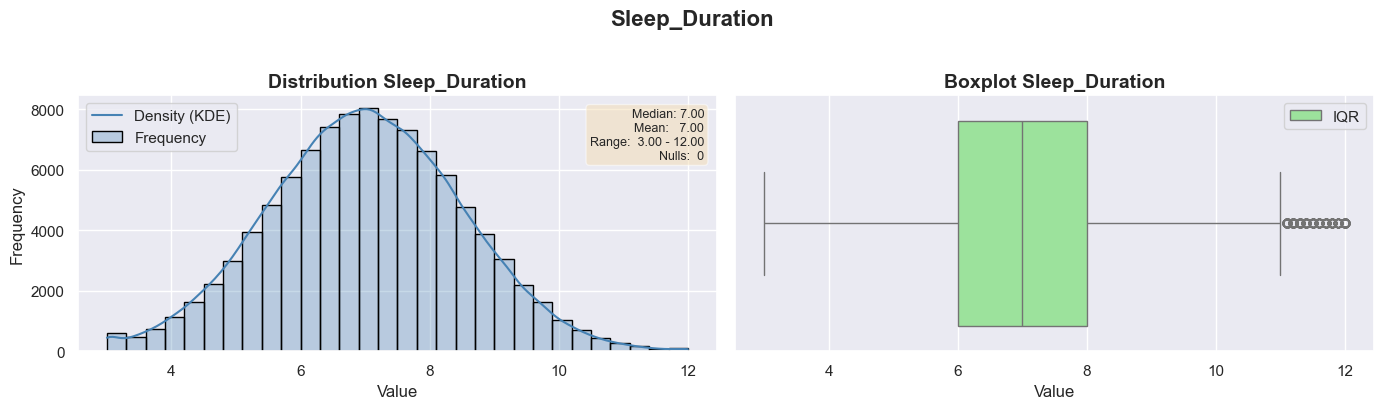

Sleep_Duration:
Пропусков: 0
Выбросов: 369


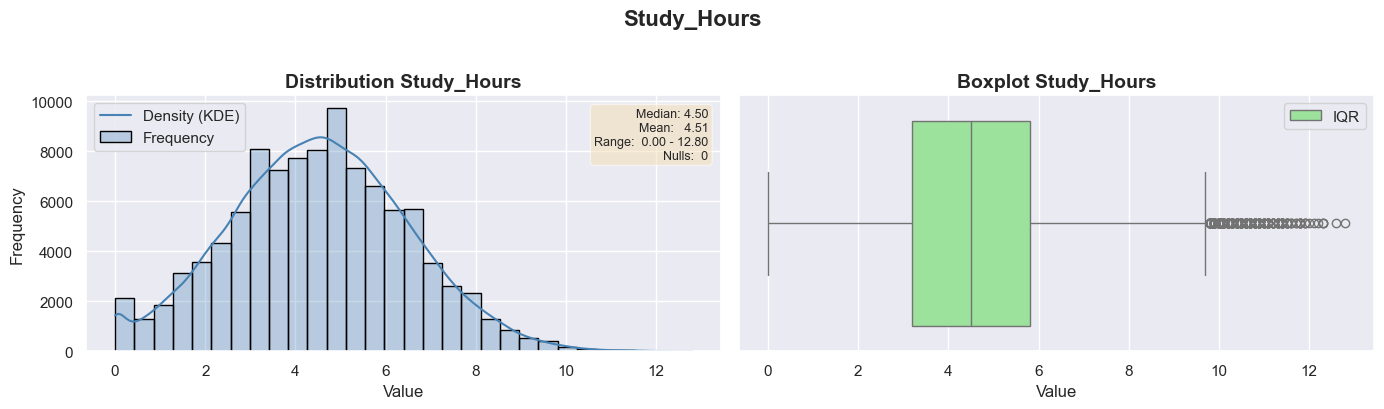

Study_Hours:
Пропусков: 0
Выбросов: 432


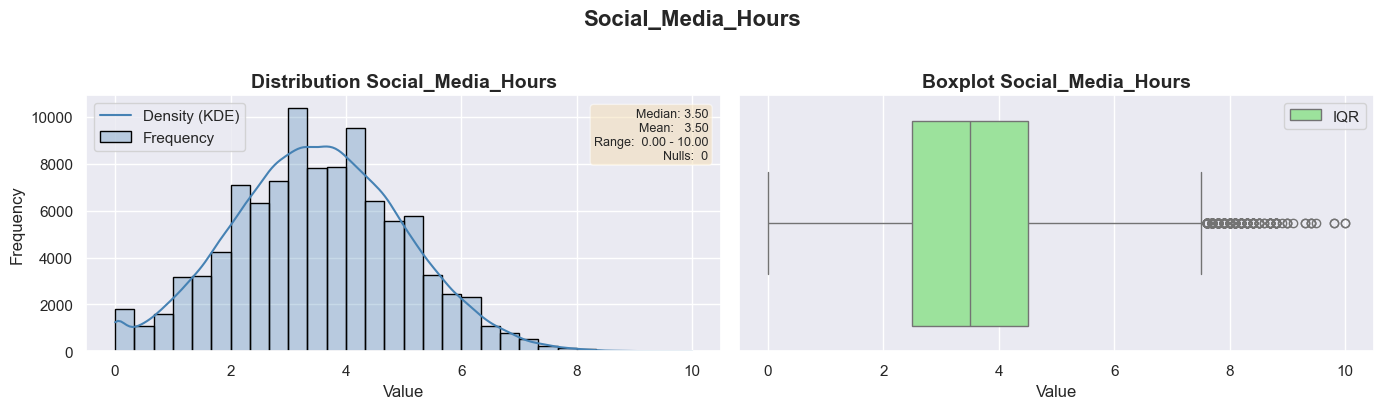

Social_Media_Hours:
Пропусков: 0
Выбросов: 328


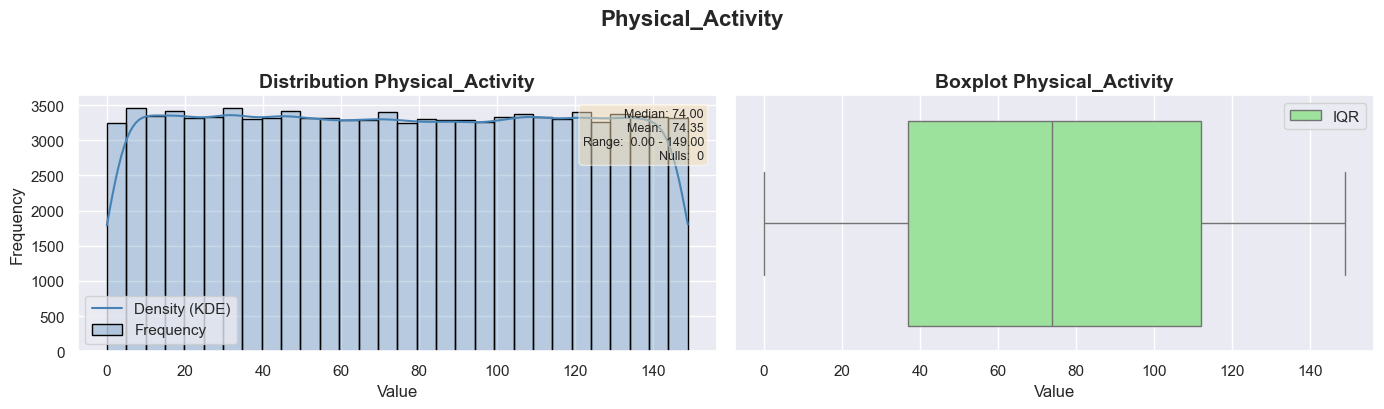

Physical_Activity:
Пропусков: 0
Выбросов: 0


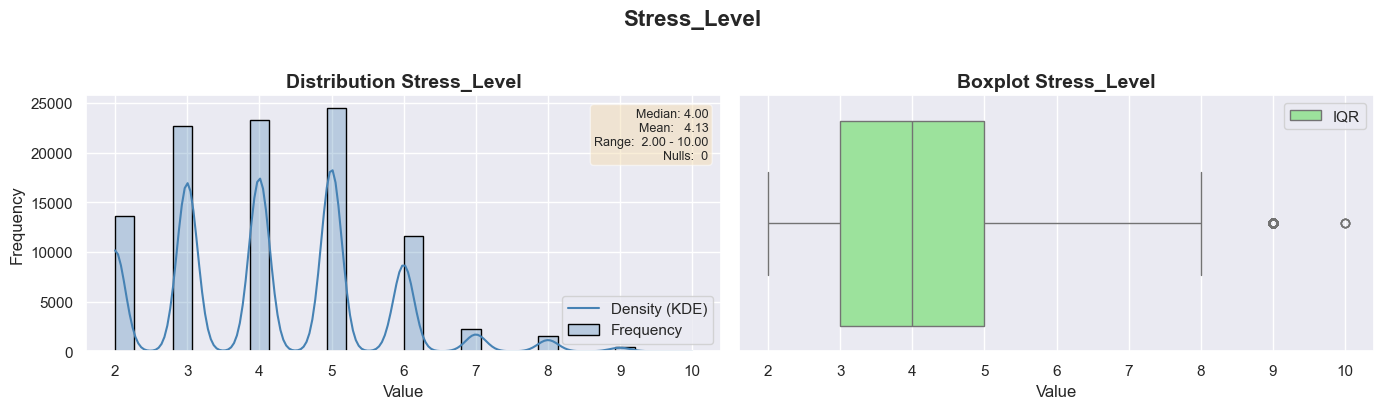

Stress_Level:
Пропусков: 0
Выбросов: 478


In [20]:
# сначала сделаем визуализации для числовых признаков
numeric_cols = df.select_dtypes(include='number').columns.tolist()

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # гистограмма с KDE
    sns.histplot(data=df, x=col, bins=30, kde=True, ax=axes[0],
                    color='steelblue', edgecolor='black', alpha=0.3)
    axes[0].set_title(f'Distribution {col}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Value')
    axes[0].set_ylabel('Frequency')
    axes[0].legend(['Density (KDE)', 'Frequency'], loc='best')

    # Boxplot (ящик с усами)
    sns.boxplot(data=df, x=col, ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Boxplot {col}', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Value')
    axes[1].legend(['IQR', 'Медиана', 'Выбросы'], loc='best')

    # медиана, среднее и разброс значений
    stats_text = (f"Median: {df[col].median():.2f}\n"
                    f"Mean:   {df[col].mean():.2f}\n"
                    f"Range:  {df[col].min():.2f} - {df[col].max():.2f}\n"
                    f"Nulls:  {df[col].isnull().sum()}")

    axes[0].text(0.98, 0.95, stats_text, transform=axes[0].transAxes,
                    fontsize=9, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.suptitle(col, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # считаем выбросы
    col_data = df[col].dropna()

    Q1 = col_data.quantile(0.25)
    Q3 = col_data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = ((col_data < lower_bound) | (col_data > upper_bound)).sum()
    missing_count = df[col].isnull().sum()


    print(f"{col}:")
    print(f"Пропусков: {missing_count}")
    print(f"Выбросов: {outliers_count}")

In [4]:
df.drop(columns=['Student_ID'], inplace=True)
df.head()

,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


Остальные колонки нам еще понадобятся, пока не будем их убирать.

ВОЗМОЖНО ЛУЧШЕ СНАЧАЛА ПРЕВРАТИТЬ КАТЕГОРИИ В ЧИСЛА

Сделаем визуализации, чтобы увидеть распределения признаков и оценить аномалии:

In [ ]:
# Выбираем только числовые колонки
numeric_cols = df.select_dtypes()